This notebook aims to conduct thorough exploratory data analysis (EDA) and build strong baseline models for churn prediction.

#### We evaluate the performance of:

* Logistic Regression
* Random Forest
* XGBoost

Instead of a simple train/test split, Stratified K-Fold cross-validation is used to obtain a more reliable estimate of generalization performance while preserving class distribution across folds.

## Importing data:

In [1]:
import pandas as pd 

train_path = '/kaggle/input/competitions/playground-series-s6e3/train.csv'
train_df = pd.read_csv(train_path)
train_df.head() #to check if the data has loaded safely

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [2]:
target = 'Churn'

#encoding the target 
train_df[target] = train_df[target].map({"No": 0, "Yes": 1}) 

#dropping redundant features ('id')
train_df = train_df.drop('id', axis=1)

#seperating features and label
X = train_df.drop(target, axis=1)
y = train_df[target]

In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMethod     59

Most of the columns/features comprise of Dtype object that is they are categorical, and a few numerical but on closer inspection we get to see that the feature "SeniorCitizen" has values 0/1 indicating true/false or yes/no so it has characteristics of a categorical feature as well.

In [4]:
X.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000
mean,0.114102,36.577258,65.866223,2494.377057
std,0.317936,25.061922,31.067444,2353.916710
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,12.000000,29.900000,639.650000
50%,0.000000,35.000000,74.100000,1433.650000
75%,0.000000,62.000000,90.800000,4263.800000
max,1.000000,72.000000,118.750000,8684.800000


I was confused wether to put tenure in categorical bucket or consider it as a numerical, turns out it represents a legal contract for a cetain period of time, though its not specified if the units of tenure is months or years but each unit has a weight holds some significant meaning so it is considered as a numerical feature.

As for "MonthlyCharges" and "TotalCharges" they are numerical features as well, and we'll have to scale them using StandardScaler, though there means seem reasonable.

Another thing i would like to experiment with during feature engineering would be converting the feature "tenure" into categorical faeture by binning it into 3 bins as small-term, medium-term, long-term.

In [5]:
#looking for null values
X.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

Thankfully theres no null values in the training data so we would not have to worry about imputation, if its the same in case of test data.

## EDA:

### 1. Checking for Outliers:

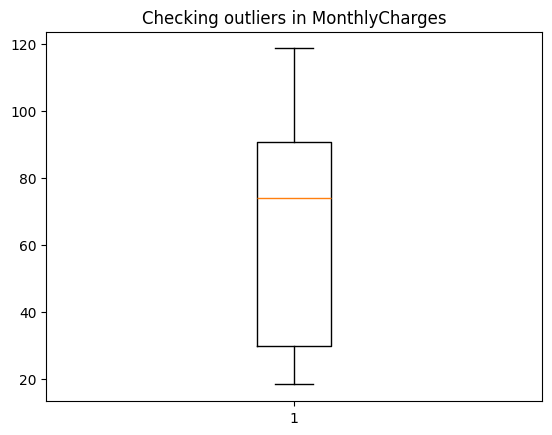

In [6]:
import matplotlib.pyplot as plt

plt.boxplot(X['MonthlyCharges'])
plt.title("Checking outliers in MonthlyCharges")
plt.show()

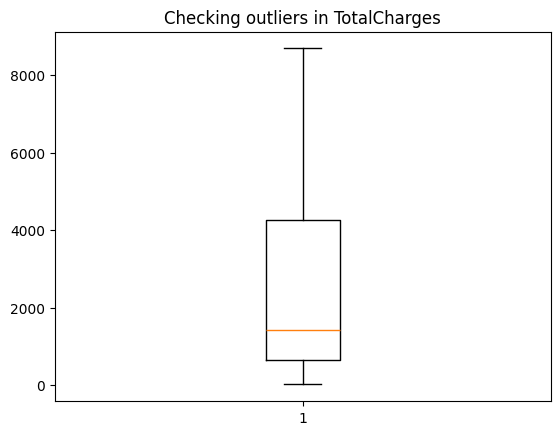

In [7]:
plt.boxplot(X['TotalCharges'])
plt.title("Checking outliers in TotalCharges")
plt.show()

Turns out theres no outliers, which is usually a good thing. We wont have to exclude any datapoints which could have led to loss of information in some cases.

### 2. Checking numerical feature distribution:

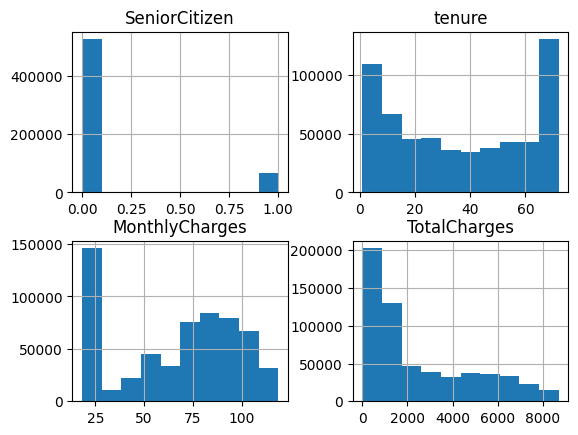

In [8]:
X.hist()
plt.show()

As mentioned above that feature "SeniorCitizen" is a categorical feature there wont be any comment made on it.

But as for MonthlyCharges and TotalCharges the datapoints are pretty much scattered:
* TotalCharges is Right Skewed
* MonthlyCharges is Right Skewed as well since large concentration of data seems to be at the lower end that is 0-30, and then it spreads towards heigher values

### 3.Target Distribution:

Counter({0: 460377, 1: 133817})


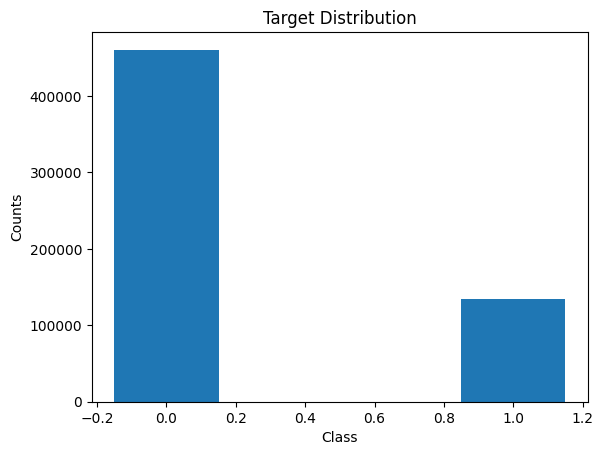

In [9]:
from collections import Counter

counts = Counter(y)
print(counts)

plt.bar(counts.keys(), counts.values(), align="center", width=0.3)
plt.xlabel("Class")
plt.ylabel("Counts")
plt.title("Target Distribution")
plt.show()

Sadly the dataset is imbalanced, that is it has more examples of the customer being retained than the cusotmer who have stopped paying for the subscription of the service, this could lead to:
* Bias towards majority class during prediction
* Misleading Accuracy(mitigate it by using confusion matrix for evaluation as well)
* Poor Generalization

## Preprocessing:
1. Scaling numerical fatures("MonthlyCharges","TotalCharges")
2. No imputation required since theres no null values invloved
3. OneHotEncoding all teh categorical features
4. No feature engineering will be involved since we are trying to establish a baseline on raw data.

#### Drop:
* id (Since its redundant)

#### Scale:
* MonthlyCharges
* TotalCharges

#### OneHot Encoding:
##### Binary Features(0/1):
* gender
* SeniorCitizens
* Partner
* Dependents
* PaperlessBilling
        
##### Categorical:
* MultipleLines
* InternetService
* OnlineSecurity
* OnlineBackup
* DeviceProtection
* TechSupport
* StreamingTV
* StramingMovies
* Contract
* PaymentMethod

Later same pipeline will be used for preprocessing test data as well.

In [10]:
cat_cols = X.select_dtypes(include="object").columns
num_cols = ["TotalCharges","MonthlyCharges"]

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

#Preprocessing pipeline
cat_pipe = Pipeline([
    ("OneHotEncoder",OneHotEncoder())
])

num_pipe = Pipeline([
    ("Scaler",StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers = [
        ("cat_cols",cat_pipe,cat_cols),
        ("num_cols",num_pipe,num_cols)
    ],
    remainder="passthrough",  #letting "SeniorCtitizen" and "tenure" passthrough 
    force_int_remainder_cols=False

)

## Training:

In [12]:
from sklearn.model_selection import StratifiedKFold

#k-folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### Models(Baseline):

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#logistic regression baseline
logreg = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

#RandomForest baseline
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

#XGB baseline
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss',
    random_state=42,
    device="cuda",
)

#### Final Pipeline:

In [14]:
from sklearn.model_selection import cross_validate

def train_n_validate(model):
    '''
    This function automates the process of training and validation,

    Input parameter: model/pipeline/estimator

    Returns scores
    '''
    
    #final_pipeline:
    pipeline = Pipeline([
        ("prep",preprocessor),
        ("model",model)
    ])
    
    #metrics for evaluation
    metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    #cross_validation
    cv_results = cross_validate(pipeline,
                        X,
                        y,
                        cv = skf,
                        scoring = metrics,
                        n_jobs = -1)

    return cv_results

#### Training and validation:

In [15]:
cv_logreg = train_n_validate(logreg)
cv_rf = train_n_validate(rf)
cv_xgb = train_n_validate(xgb)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [18:07:30] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [18:07:30] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This m

In [16]:
cv_logreg.items()

dict_items([('fit_time', array([25.04516363, 24.83779931, 30.46827817, 27.25084352, 19.30961561])), ('score_time', array([1.61671305, 1.65378952, 0.95064592, 1.07174468, 0.87666774])), ('test_accuracy', array([0.85302805, 0.85509807, 0.85466051, 0.85586382, 0.85394402])), ('test_precision', array([0.6819445 , 0.68471991, 0.68433931, 0.6904376 , 0.68320997])), ('test_recall', array([0.65101072, 0.66087509, 0.65830967, 0.65259304, 0.6553077 ])), ('test_f1', array([0.66611867, 0.67258623, 0.67107218, 0.67098212, 0.66896802])), ('test_roc_auc', array([0.90746724, 0.90887798, 0.90808356, 0.9091335 , 0.90613128]))])

#### Displaying scores:

In [17]:
def return_df(model_name,cv_results):
    '''
    Returns a dataframe with model and models performance across all metrics it was scored on
    
    Parameters: model_name and cv_results returned from "train_n_validate" function defined above
    '''

    df = pd.DataFrame({
        "model" : [model_name],
        "accuracy" : [cv_results['test_accuracy'].mean()],
        "precision" : [cv_results['test_precision'].mean()],
        "recall" : [cv_results["test_recall"].mean()],
        "f1" : [cv_results["test_f1"].mean()],
        "roc_auc" : [cv_results["test_roc_auc"].mean()]
    })

    return df

In [18]:
scores_logreg = return_df("Logistic Regression",cv_logreg) 
scores_rf = return_df("RandomForest",cv_rf) 
scores_xgb = return_df("XGBoost",cv_xgb) 

all_scores = pd.concat(
    [scores_logreg, scores_rf, scores_xgb],
    axis=0
)

all_scores.head()

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.854519,0.684930,0.655619,0.669945,0.907939
0,RandomForest,0.841219,0.666392,0.590657,0.626237,0.890666
0,XGBoost,0.860424,0.710309,0.642146,0.674503,0.915296


As can be observed from the above table that XGBoost performs best out of all 3 used baseline models across all 3 metrics. Followed by Logistic Regression and finally RandomForestClassifier. Though the f1 scores and recall are pretty low in case of XGBoost baseline.

## Retraining best performing model:
This time complete dataset will be used for training. Finally we'll make predictions on the test data.

In [19]:
final_pipeline = Pipeline([
    ("prep",preprocessor),
    ("model",xgb)
])

final_pipeline.fit(X,y)

Pipeline(steps=[('prep',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('cat_cols',
                                                  Pipeline(steps=[('OneHotEncoder',
                                                                   OneHotEncoder())]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'Streami...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

**Checking Feature Impotance:**

In [20]:
model = final_pipeline.named_steps["model"]

#extracting feature names and there importance out from the pipeline
importances = model.feature_importances_
feature_names = final_pipeline.named_steps['prep'].get_feature_names_out()

In [21]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance.head(35)

,Feature,Importance
32,cat_cols__Contract_Month-to-month,0.517908
12,cat_cols__InternetService_Fiber optic,0.294521
39,cat_cols__PaymentMethod_Electronic check,0.060254
34,cat_cols__Contract_Two year,0.020144
33,cat_cols__Contract_One year,0.013598
11,cat_cols__InternetService_DSL,0.010972
44,remainder__tenure,0.010077
14,cat_cols__OnlineSecurity_No,0.008751
23,cat_cols__TechSupport_No,0.007903
26,cat_cols__StreamingTV_No,0.007729


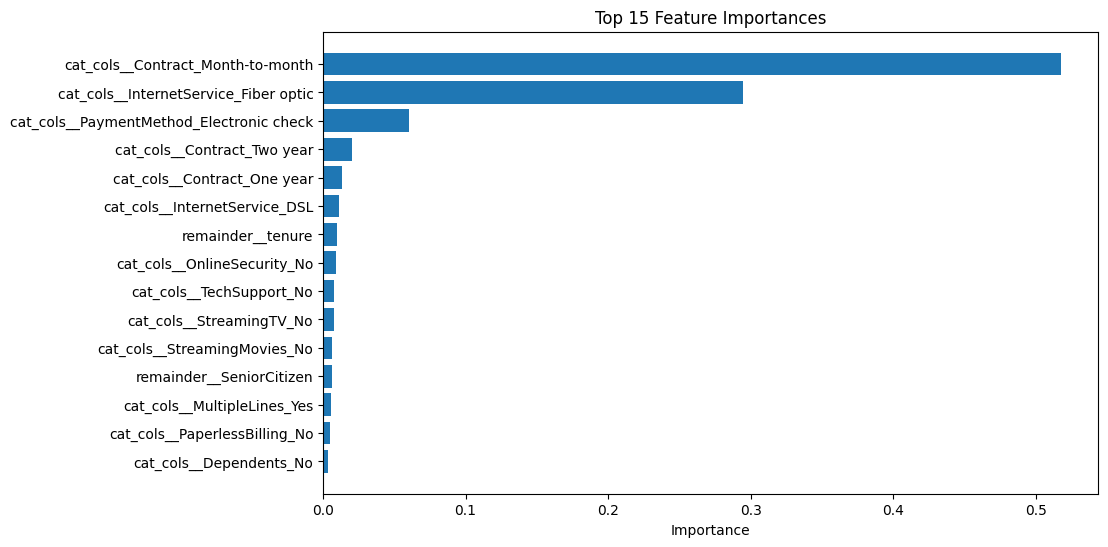

In [22]:
#plotting feature importance

plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"][:15], feature_importance["Importance"][:15])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances")
plt.show()

## Predicting on test data:

In [23]:
test_path = "/kaggle/input/competitions/playground-series-s6e3/test.csv"
test_df = pd.read_csv(test_path)
test_df.head() #to check if the data has loaded safely

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,594197,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,594198,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


In [24]:
#dropping redundant columns:
X_test = test_df.drop('id', axis=1)

X_test.isna().sum() #checking for null values

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64

As i anticipated theres no null values present. We can proceed with predicting on the test data. 

In [25]:
y_pred = final_pipeline.predict_proba(X_test)[:,1]

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:774: UserWarning: [18:07:45] WARNING: /workspace/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


In [26]:
submission = pd.DataFrame({
    'id' : test_df['id'],
    'Churn' : y_pred
})

submission.to_csv("submission.csv", index=False)